# 라이브러리 호출 및 주피터 환경 설정

In [1]:
# 경고 메시지 숨기기 (깔끔한 출력을 위해)
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# 주피터 노트북 내에 그래프를 바로 표시하는 매직 명령어
%matplotlib inline

# 운영체제별 한글 폰트 자동 설정
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥(Mac)
else:
    plt.rc('font', family='NanumGothic')    # 리눅스 등

plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 기호 깨짐 방지

# 가상 데이터 생성 및 스케일링

In [2]:
# 1. 3개의 군집을 가진 300명의 가상 고객 데이터 생성 (연봉, 소비지수)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
df = pd.DataFrame(X, columns=['연봉(단위: 천만원)', '소비 지수(1~100)'])

# 2. 필수 주의점: 데이터 스케일링 (평균 0, 표준편차 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 스케일링 완료된 데이터 상위 5개 확인
print("스케일링 전 데이터 (df.head()):\n", df.head(), "\n")
print("스케일링 후 데이터 (X_scaled 상위 5개):\n", X_scaled[:5])

스케일링 전 데이터 (df.head()):
    연봉(단위: 천만원)  소비 지수(1~100)
0    -7.338988     -7.729954
1    -7.740041     -7.264665
2    -1.686653      7.793442
3     4.422198      3.071947
4    -8.917752     -7.888196 

스케일링 후 데이터 (X_scaled 상위 5개):
 [[-1.17252292 -1.37037478]
 [-1.25431875 -1.30020394]
 [-0.01971253  0.97072996]
 [ 1.22620543  0.25867467]
 [-1.49451639 -1.39423947]]


# K-means 클러스터링 실행 및 시각화
n_init=10 옵션을 통해 초기값을 다르게 하여 여러 번 시도하는(복불복 방지) K-means를 실행

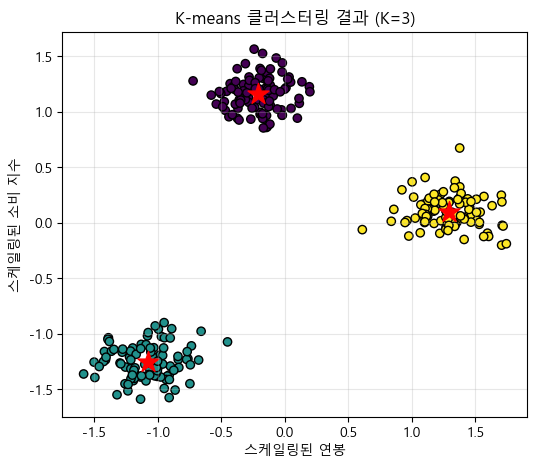

In [3]:
# K=3으로 설정하고, 무작위 초기화를 10번 반복하여 최적의 결과 선택
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# 시각화
plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', edgecolor='k')
# 빨간색 별 모양으로 군집의 중심점(Centroid) 표시
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=250, c='red', marker='*') 

plt.title('K-means 클러스터링 결과 (K=3)')
plt.xlabel('스케일링된 연봉')
plt.ylabel('스케일링된 소비 지수')
plt.grid(True, alpha=0.3)
plt.show()

# 계층적 군집과 덴드로그램 (링크 유형 비교하기)

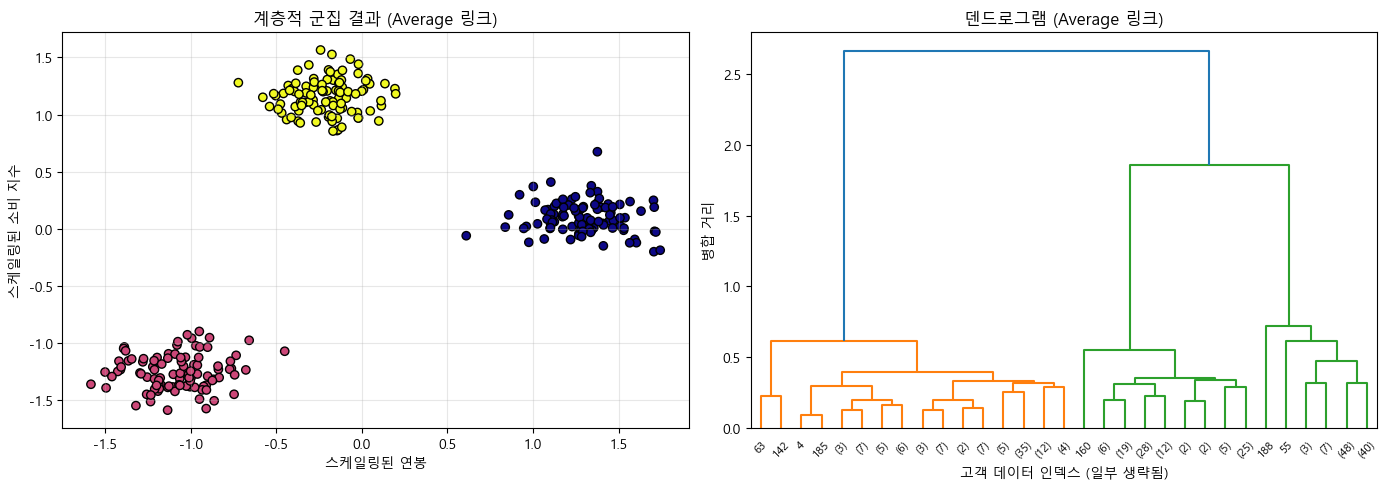

In [10]:
# 화면을 반으로 나누어 왼쪽엔 산점도, 오른쪽엔 덴드로그램 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 계층적 군집 (Average 링크, K=3 기준)
hc = AgglomerativeClustering(n_clusters=3, linkage='average')
hc_labels = hc.fit_predict(X_scaled)

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=hc_labels, cmap='plasma', edgecolor='k')
axes[0].set_title('계층적 군집 결과 (Average 링크)')
axes[0].set_xlabel('스케일링된 연봉')
axes[0].set_ylabel('스케일링된 소비 지수')
axes[0].grid(True, alpha=0.3)

# 2. 덴드로그램 (전체 가계도 구조 보기)
# 여기서 method='average'를 'single', 'complete', 'ward'로 바꿔서 실행해보세요!
linked = linkage(X_scaled, method='average')

dendrogram(linked, ax=axes[1], truncate_mode='level', p=5) # 보기 좋게 상위 5단계만 자름
axes[1].set_title('덴드로그램 (Average 링크)')
axes[1].set_xlabel('고객 데이터 인덱스 (일부 생략됨)')
axes[1].set_ylabel('병합 거리')

plt.tight_layout()
plt.show()

# K-means 최적의 K 찾기: 엘보우 기법 (Elbow Method)

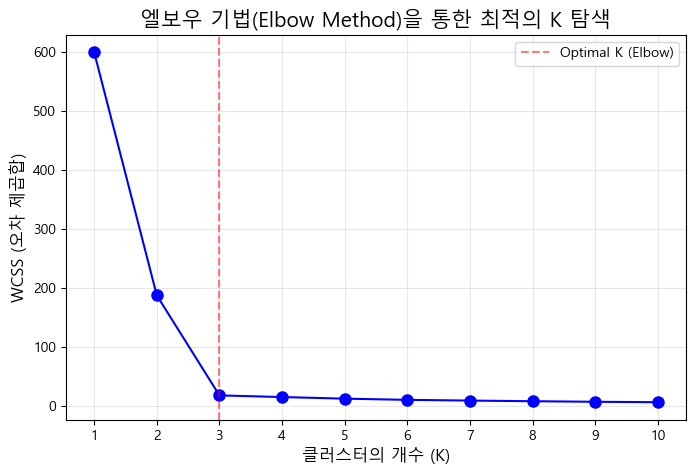

In [11]:
# WCSS(Within-Cluster Sum of Squares) 값을 저장할 빈 리스트 생성
wcss = []

# K값을 1부터 10까지 변화시키면서 K-means 모델을 학습
K_range = range(1, 11)
for k in K_range:
    # n_init=10 옵션으로 초기화 복불복을 방지하며 모델 생성
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    
    # 모델 학습 후, inertia_ 속성에 저장된 WCSS 값을 리스트에 추가
    wcss.append(kmeans.inertia_)

# 엘보우 그래프 시각화
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='b', markersize=8)

plt.title('엘보우 기법(Elbow Method)을 통한 최적의 K 탐색', fontsize=15)
plt.xlabel('클러스터의 개수 (K)', fontsize=12)
plt.ylabel('WCSS (오차 제곱합)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

# 꺾이는 지점(K=3)에 눈에 띄게 표시를 추가 (선택 사항)
plt.axvline(x=3, color='r', linestyle='--', alpha=0.5, label='Optimal K (Elbow)')
plt.legend()

plt.show()